# Лабораторная работа №2

## Моделирование плоских линий

В ноутбуке выполнены все четыре задания второй лабораторной:
- преобразование квадрики;
- исследование кривизны двух кривых;
- анализ и преобразование кривых Безье, а также моделирование контура объекта;
- растровое изображение отрезка двумя алгоритмами.

Для вычислений и визуализации используются только `numpy` и `matplotlib`.


In [1]:
import math
from itertools import permutations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)


## Вспомогательные функции

Здесь собраны функции для:
- однородных координат и аффинных матриц;
- работы с квадриками;
- вычисления касательных, нормалей, кривизны и эволют;
- кривых Безье и сплайна Катмулла-Рома;
- растеризации отрезка.


In [2]:
def to_homogeneous(points: np.ndarray) -> np.ndarray:
    points = np.asarray(points, dtype=float)
    return np.vstack([points.T, np.ones(points.shape[0])])


def from_homogeneous(points_h: np.ndarray) -> np.ndarray:
    return (points_h[:2] / points_h[2]).T


def apply_transform(matrix: np.ndarray, points: np.ndarray) -> np.ndarray:
    return from_homogeneous(matrix @ to_homogeneous(points))


def translation(tx: float, ty: float) -> np.ndarray:
    return np.array([
        [1.0, 0.0, tx],
        [0.0, 1.0, ty],
        [0.0, 0.0, 1.0],
    ])


def rotation(angle_deg: float) -> np.ndarray:
    angle = math.radians(angle_deg)
    c, s = math.cos(angle), math.sin(angle)
    return np.array([
        [c, -s, 0.0],
        [s, c, 0.0],
        [0.0, 0.0, 1.0],
    ])


def scaling(kx: float, ky: float) -> np.ndarray:
    return np.array([
        [kx, 0.0, 0.0],
        [0.0, ky, 0.0],
        [0.0, 0.0, 1.0],
    ])


def rotation_about(angle_deg: float, center: tuple[float, float]) -> np.ndarray:
    cx, cy = center
    return translation(cx, cy) @ rotation(angle_deg) @ translation(-cx, -cy)


def print_matrix(name: str, matrix: np.ndarray) -> None:
    print(f"{name} =")
    print(np.array_str(matrix, precision=4, suppress_small=True))
    print()


def print_points(name: str, points: np.ndarray) -> None:
    print(f"{name} =")
    print(np.array_str(points, precision=4, suppress_small=True))
    print()


def conic_coefficients(conic: np.ndarray) -> tuple[float, float, float, float, float, float]:
    a = conic[0, 0]
    b = 2 * conic[0, 1]
    c = conic[1, 1]
    d = 2 * conic[0, 2]
    e = 2 * conic[1, 2]
    f = conic[2, 2]
    return a, b, c, d, e, f


def evaluate_conic(conic: np.ndarray, x: np.ndarray, y: np.ndarray) -> np.ndarray:
    a, b, c, d, e, f = conic_coefficients(conic)
    return a * x ** 2 + b * x * y + c * y ** 2 + d * x + e * y + f


def format_conic(conic: np.ndarray) -> str:
    names = ["x^2", "xy", "y^2", "x", "y", "1"]
    coeffs = conic_coefficients(conic)
    parts = []
    for coeff, name in zip(coeffs, names):
        if abs(coeff) < 1e-10:
            continue
        sign = "+" if coeff > 0 else "-"
        value = abs(coeff)
        if name == "1":
            term = f"{value:.4f}"
        elif abs(value - 1.0) < 1e-10:
            term = name
        else:
            term = f"{value:.4f}{name}"
        parts.append((sign, term))
    if not parts:
        return "0 = 0"
    first_sign, first_term = parts[0]
    expression = ("" if first_sign == "+" else "- ") + first_term
    for sign, term in parts[1:]:
        expression += f" {sign} {term}"
    return expression + " = 0"


def plot_vector(ax, origin: np.ndarray, vector: np.ndarray, color: str, label: str) -> None:
    ax.annotate(
        "",
        xy=origin + vector,
        xytext=origin,
        arrowprops=dict(arrowstyle="->", color=color, linewidth=2),
    )
    ax.text(*(origin + vector + np.array([0.1, 0.1])), label, color=color)


def tangent_data(point_fn, d1_fn, d2_fn, t0: float) -> dict[str, np.ndarray | float]:
    point = point_fn(t0)
    d1 = d1_fn(t0)
    d2 = d2_fn(t0)
    speed = np.linalg.norm(d1)
    tangent = d1 / speed
    left_normal = np.array([-tangent[1], tangent[0]])
    signed_curvature = (d1[0] * d2[1] - d1[1] * d2[0]) / speed ** 3
    radius = math.inf if abs(signed_curvature) < 1e-12 else 1.0 / abs(signed_curvature)
    center = point + left_normal / signed_curvature
    principal_normal = center - point
    principal_normal /= np.linalg.norm(principal_normal)
    return {
        "point": point,
        "d1": d1,
        "d2": d2,
        "tangent": tangent,
        "normal": principal_normal,
        "curvature": signed_curvature,
        "radius": radius,
        "center": center,
    }


def evolute_points(point_fn, d1_fn, d2_fn, ts: np.ndarray) -> np.ndarray:
    centers = []
    for t in ts:
        data = tangent_data(point_fn, d1_fn, d2_fn, float(t))
        centers.append(data["center"])
    return np.array(centers)


def bezier_quadratic(control: np.ndarray, t: np.ndarray) -> np.ndarray:
    control = np.asarray(control, dtype=float)
    t = np.asarray(t, dtype=float)
    return ((1 - t) ** 2)[:, None] * control[0] + (2 * (1 - t) * t)[:, None] * control[1] + (t ** 2)[:, None] * control[2]


def bezier_cubic(control: np.ndarray, t: np.ndarray) -> np.ndarray:
    control = np.asarray(control, dtype=float)
    t = np.asarray(t, dtype=float)
    return ((1 - t) ** 3)[:, None] * control[0] + (3 * (1 - t) ** 2 * t)[:, None] * control[1] + (3 * (1 - t) * t ** 2)[:, None] * control[2] + (t ** 3)[:, None] * control[3]


def bezier_power_coeffs(control: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    p = np.asarray(control, dtype=float)
    a = -p[0] + 3 * p[1] - 3 * p[2] + p[3]
    b = 3 * p[0] - 6 * p[1] + 3 * p[2]
    c = -3 * p[0] + 3 * p[1]
    d = p[0]
    return a, b, c, d


def bezier_cubic_d1(control: np.ndarray, t: float) -> np.ndarray:
    p = np.asarray(control, dtype=float)
    return 3 * ((1 - t) ** 2 * (p[1] - p[0]) + 2 * (1 - t) * t * (p[2] - p[1]) + t ** 2 * (p[3] - p[2]))


def bezier_cubic_d2(control: np.ndarray, t: float) -> np.ndarray:
    p = np.asarray(control, dtype=float)
    return 6 * ((1 - t) * (p[2] - 2 * p[1] + p[0]) + t * (p[3] - 2 * p[2] + p[1]))


def bezier_cusp_parameters(control: np.ndarray) -> list[float]:
    a, b, c, _ = bezier_power_coeffs(control)
    roots = []
    for component in range(2):
        poly = [3 * a[component], 2 * b[component], c[component]]
        if abs(poly[0]) < 1e-12:
            if abs(poly[1]) < 1e-12:
                continue
            candidates = [-poly[2] / poly[1]]
        else:
            candidates = np.roots(poly)
        for root in candidates:
            if abs(getattr(root, "imag", 0.0)) < 1e-10:
                t = float(np.real(root))
                if 1e-9 < t < 1 - 1e-9:
                    if np.linalg.norm(3 * a * t ** 2 + 2 * b * t + c) < 1e-8:
                        if not any(abs(t - saved) < 1e-6 for saved in roots):
                            roots.append(t)
    return sorted(roots)


def bezier_self_intersection_parameters(control: np.ndarray) -> list[tuple[float, float]]:
    a, b, c, _ = bezier_power_coeffs(control)
    cross = lambda u, v: u[0] * v[1] - u[1] * v[0]
    det = cross(a, b)
    if abs(det) < 1e-12:
        if abs(cross(a, c)) > 1e-12 or abs(cross(b, c)) > 1e-12:
            return []
        return []
    q, u = np.linalg.solve(np.array([[a[0], b[0]], [a[1], b[1]]], dtype=float), -c)
    v = u ** 2 - q
    disc = u ** 2 - 4 * v
    if disc <= 1e-12:
        return []
    root = math.sqrt(disc)
    t1 = (u + root) / 2
    t2 = (u - root) / 2
    if 1e-9 < t1 < 1 - 1e-9 and 1e-9 < t2 < 1 - 1e-9 and abs(t1 - t2) > 1e-8:
        return [tuple(sorted((float(t1), float(t2))))]
    return []


def catmull_rom_open(points: np.ndarray, samples_per_segment: int = 60) -> np.ndarray:
    points = np.asarray(points, dtype=float)
    padded = np.vstack([points[0], points, points[-1]])
    segments = []
    for i in range(1, len(padded) - 2):
        p0, p1, p2, p3 = padded[i - 1:i + 3]
        t_values = np.linspace(0.0, 1.0, samples_per_segment, endpoint=False)
        for t in t_values:
            point = 0.5 * (
                (2 * p1)
                + (-p0 + p2) * t
                + (2 * p0 - 5 * p1 + 4 * p2 - p3) * t ** 2
                + (-p0 + 3 * p1 - 3 * p2 + p3) * t ** 3
            )
            segments.append(point)
    segments.append(points[-1])
    return np.array(segments)


def natural_line_pixels(start: np.ndarray, end: np.ndarray) -> list[tuple[int, int]]:
    x0, y0 = map(float, start)
    x1, y1 = map(float, end)
    dx, dy = x1 - x0, y1 - y0
    if abs(dx) >= abs(dy):
        slope = dy / dx if abs(dx) > 1e-12 else 0.0
        step = 1 if dx >= 0 else -1
        return [(x, int(round(y0 + slope * (x - x0)))) for x in range(round(x0), round(x1) + step, step)]
    slope = dx / dy if abs(dy) > 1e-12 else 0.0
    step = 1 if dy >= 0 else -1
    return [(int(round(x0 + slope * (y - y0))), y) for y in range(round(y0), round(y1) + step, step)]


def bresenham_line(start: np.ndarray, end: np.ndarray) -> list[tuple[int, int]]:
    x0, y0 = map(int, map(round, start))
    x1, y1 = map(int, map(round, end))
    pixels = []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy
    while True:
        pixels.append((x0, y0))
        if x0 == x1 and y0 == y1:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x0 += sx
        if e2 < dx:
            err += dx
            y0 += sy
    return pixels


def draw_raster(ax, pixels: list[tuple[int, int]], start: np.ndarray, end: np.ndarray, title: str, pixel_color: str, exact_start: np.ndarray | None = None, exact_end: np.ndarray | None = None) -> None:
    xs = [point[0] for point in pixels]
    ys = [point[1] for point in pixels]
    ax.scatter(xs, ys, s=260, marker="s", facecolors="none", edgecolors=pixel_color, linewidths=1.8, label="Пиксели")
    ax.plot([start[0], end[0]], [start[1], end[1]], color="black", linewidth=1.6, label="Отрезок по узлам")
    if exact_start is not None and exact_end is not None:
        ax.plot([exact_start[0], exact_end[0]], [exact_start[1], exact_end[1]], linestyle="--", color="tab:orange", linewidth=1.6, label="Точный отрезок")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks(range(min(xs + [round(start[0]), round(end[0])]) - 1, max(xs + [round(start[0]), round(end[0])]) + 2))
    ax.set_yticks(range(min(ys + [round(start[1]), round(end[1])]) - 1, max(ys + [round(start[1]), round(end[1])]) + 2))
    ax.grid(True, which="both")
    ax.legend(loc="upper left")


## Задание 2.1. Преобразование квадрики

Введем систему координат так, что:
- начало координат `O = (0, 0)` совпадает с центром эллипса;
- оси `Ox` и `Oy` направлены вдоль главных осей эллипса.

Выберем:
- исходную окружность радиуса `R = 4`;
- эллипс с полуосями `a = 6`, `b = 3`.

Тогда аффинное преобразование, переводящее окружность в эллипс, имеет вид

`F = diag(a / R, b / R, 1) = diag(1.5, 0.75, 1)`.

Для квадрики в однородных координатах используется матричная запись

`[x, y, 1] C [x, y, 1]^T = 0`,

а при замене переменных `x' = F x` матрица квадрики преобразуется по формуле

`C' = F^{-T} C F^{-1}`.


In [3]:
radius = 4.0
semi_axes = np.array([6.0, 3.0])

circle_conic = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, -radius ** 2],
])

affine_quadric = scaling(semi_axes[0] / radius, semi_axes[1] / radius)
ellipse_conic = np.linalg.inv(affine_quadric).T @ circle_conic @ np.linalg.inv(affine_quadric)

theta = np.linspace(0.0, 2 * math.pi, 500)
circle_points = np.column_stack([radius * np.cos(theta), radius * np.sin(theta)])
ellipse_points = apply_transform(affine_quadric, circle_points)

print_matrix("Матрица окружности C", circle_conic)
print_matrix("Матрица аффинного преобразования F", affine_quadric)
print_matrix("Матрица эллипса C'", ellipse_conic)

print("Уравнение окружности:", format_conic(circle_conic))
print("Уравнение образа:", format_conic(ellipse_conic))
print("Нормированное уравнение эллипса: x^2 / 36 + y^2 / 9 = 1")
print()
print("Максимальное отклонение геометрического образа от аналитического уравнения:",
      np.max(np.abs(evaluate_conic(ellipse_conic, ellipse_points[:, 0], ellipse_points[:, 1]))))


Матрица окружности C =
[[  1.   0.   0.]
 [  0.   1.   0.]
 [  0.   0. -16.]]

Матрица аффинного преобразования F =
[[1.5  0.   0.  ]
 [0.   0.75 0.  ]
 [0.   0.   1.  ]]

Матрица эллипса C' =
[[  0.4444   0.       0.    ]
 [  0.       1.7778   0.    ]
 [  0.       0.     -16.    ]]

Уравнение окружности: x^2 + y^2 - 16.0000 = 0
Уравнение образа: 0.4444x^2 + 1.7778y^2 - 16.0000 = 0
Нормированное уравнение эллипса: x^2 / 36 + y^2 / 9 = 1

Максимальное отклонение геометрического образа от аналитического уравнения: 7.105427357601002e-15


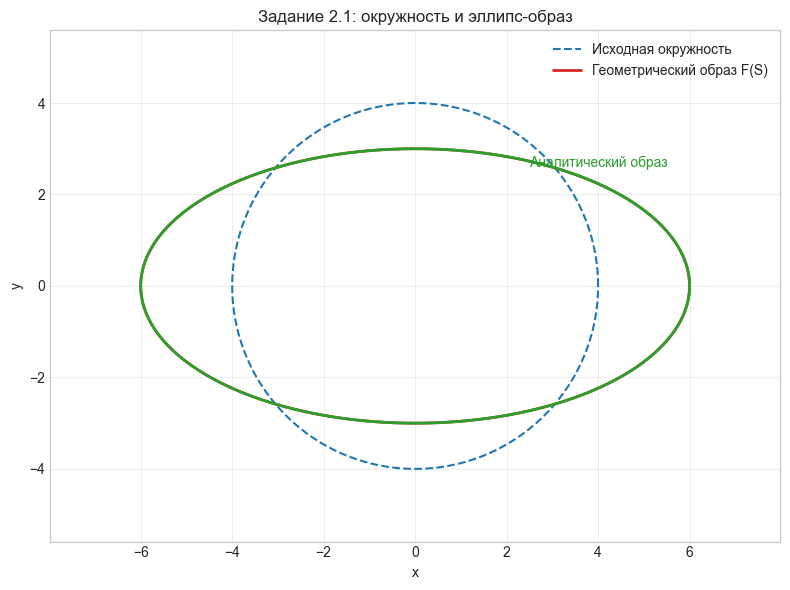

In [4]:
x_grid = np.linspace(-7.5, 7.5, 400)
y_grid = np.linspace(-4.5, 4.5, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z = evaluate_conic(ellipse_conic, X, Y)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(circle_points[:, 0], circle_points[:, 1], linestyle="--", color="tab:blue", label="Исходная окружность")
ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], color="tab:red", linewidth=2, label="Геометрический образ F(S)")
ax.contour(X, Y, Z, levels=[0], colors=["tab:green"], linewidths=2)
ax.text(2.5, 2.6, "Аналитический образ", color="tab:green")

ax.set_title("Задание 2.1: окружность и эллипс-образ")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis("equal")
ax.legend()
plt.tight_layout()
plt.show()


## Задание 2.2. Кривизна кривой

Выбраны две кривые:

1. Из первой категории: эллипс

`γ_1(t) = (5 cos t, 3 sin t),  t ∈ [0, 2π]`

`κ_1(t) = 15 / (25 sin^2 t + 9 cos^2 t)^(3/2),  ρ_1(t) = 1 / κ_1(t)`

2. Из второй категории: архимедова спираль

`γ_2(θ) = ((1 + 0.35θ) cos θ, (1 + 0.35θ) sin θ),  θ ≥ 0`

Для полярной формы `r(θ) = 1 + 0.35θ` имеем

`κ_2(θ) = (r(θ)^2 + 2 * 0.35^2) / (r(θ)^2 + 0.35^2)^(3/2),  ρ_2(θ) = 1 / κ_2(θ)`

Для любой параметрической кривой `r(t) = (x(t), y(t))` используем:

- касательный вектор `τ(t) = r'(t)`;
- кривизну `κ(t) = (x'(t) y''(t) - y'(t) x''(t)) / ||r'(t)||^3`;
- центр кривизны `C(t) = r(t) + n_left(t) / κ(t)`, где `n_left(t)` — левый единичный нормальный вектор.

Зафиксируем точки:
- на эллипсе: `t_0 = π / 4`;
- на спирали: `θ_0 = π`.


In [5]:
ellipse_a, ellipse_b = 5.0, 3.0
ellipse_t0 = math.pi / 4


def ellipse_point(t: float) -> np.ndarray:
    return np.array([ellipse_a * math.cos(t), ellipse_b * math.sin(t)])


def ellipse_d1(t: float) -> np.ndarray:
    return np.array([-ellipse_a * math.sin(t), ellipse_b * math.cos(t)])


def ellipse_d2(t: float) -> np.ndarray:
    return np.array([-ellipse_a * math.cos(t), -ellipse_b * math.sin(t)])


spiral_alpha, spiral_beta = 1.0, 0.35
spiral_t0 = math.pi


def spiral_radius(theta: float) -> float:
    return spiral_alpha + spiral_beta * theta


def spiral_point(theta: float) -> np.ndarray:
    r = spiral_radius(theta)
    return np.array([r * math.cos(theta), r * math.sin(theta)])


def spiral_d1(theta: float) -> np.ndarray:
    r = spiral_radius(theta)
    return np.array([
        spiral_beta * math.cos(theta) - r * math.sin(theta),
        spiral_beta * math.sin(theta) + r * math.cos(theta),
    ])


def spiral_d2(theta: float) -> np.ndarray:
    r = spiral_radius(theta)
    return np.array([
        -2 * spiral_beta * math.sin(theta) - r * math.cos(theta),
        2 * spiral_beta * math.cos(theta) - r * math.sin(theta),
    ])


ellipse_ts = np.linspace(0.0, 2 * math.pi, 600)
spiral_ts = np.linspace(0.0, 6 * math.pi, 1200)

ellipse_curve = np.array([ellipse_point(t) for t in ellipse_ts])
spiral_curve = np.array([spiral_point(theta) for theta in spiral_ts])

ellipse_data = tangent_data(ellipse_point, ellipse_d1, ellipse_d2, ellipse_t0)
spiral_data = tangent_data(spiral_point, spiral_d1, spiral_d2, spiral_t0)

ellipse_evolute = evolute_points(ellipse_point, ellipse_d1, ellipse_d2, ellipse_ts)
spiral_evolute = evolute_points(spiral_point, spiral_d1, spiral_d2, spiral_ts)

print("Эллипс")
print("Точка на кривой:", ellipse_data["point"])
print("Касательный вектор:", ellipse_data["d1"])
print("Единичный нормальный вектор:", ellipse_data["normal"])
print("Кривизна:", ellipse_data["curvature"])
print("Радиус кривизны:", ellipse_data["radius"])
print()

print("Архимедова спираль")
print("Точка на кривой:", spiral_data["point"])
print("Касательный вектор:", spiral_data["d1"])
print("Единичный нормальный вектор:", spiral_data["normal"])
print("Кривизна:", spiral_data["curvature"])
print("Радиус кривизны:", spiral_data["radius"])


Эллипс
Точка на кривой: [3.5355 2.1213]
Касательный вектор: [-3.5355  2.1213]
Единичный нормальный вектор: [-0.5145 -0.8575]
Кривизна: 0.21400202209088204
Радиус кривизны: 4.672853042366682

Архимедова спираль
Точка на кривой: [-2.0996  0.    ]
Касательный вектор: [-0.35   -2.0996]
Единичный нормальный вектор: [ 0.9864 -0.1644]
Кривизна: 0.48251044222151573
Радиус кривизны: 2.072494007375098


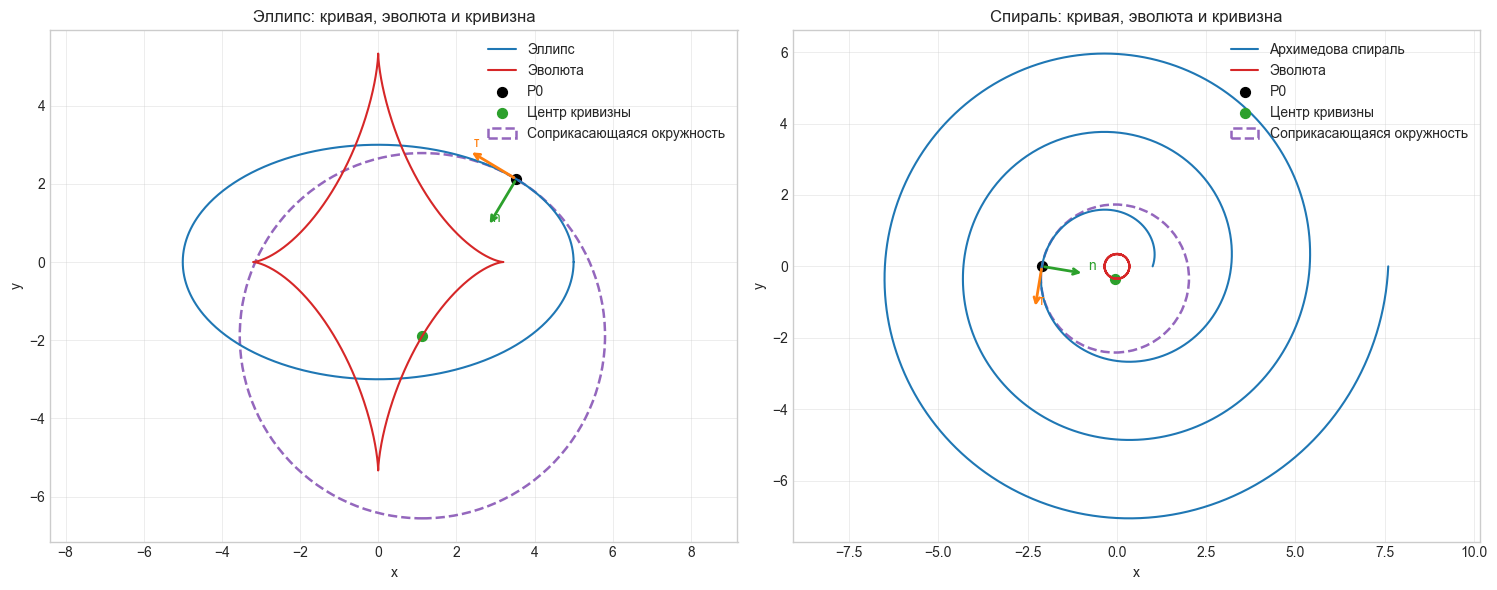

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(ellipse_curve[:, 0], ellipse_curve[:, 1], color="tab:blue", label="Эллипс")
axes[0].plot(ellipse_evolute[:, 0], ellipse_evolute[:, 1], color="tab:red", label="Эволюта")
axes[0].scatter(*ellipse_data["point"], color="black", s=50, label="P0")
axes[0].scatter(*ellipse_data["center"], color="tab:green", s=50, label="Центр кривизны")
axes[0].add_patch(Circle(ellipse_data["center"], ellipse_data["radius"], fill=False, color="tab:purple", linestyle="--", linewidth=1.8, label="Соприкасающаяся окружность"))
plot_vector(axes[0], ellipse_data["point"], ellipse_data["tangent"] * 1.4, "tab:orange", "τ")
plot_vector(axes[0], ellipse_data["point"], ellipse_data["normal"] * 1.4, "tab:green", "n")
axes[0].set_title("Эллипс: кривая, эволюта и кривизна")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].axis("equal")
axes[0].legend(loc="upper right")

axes[1].plot(spiral_curve[:, 0], spiral_curve[:, 1], color="tab:blue", label="Архимедова спираль")
axes[1].plot(spiral_evolute[:, 0], spiral_evolute[:, 1], color="tab:red", label="Эволюта")
axes[1].scatter(*spiral_data["point"], color="black", s=50, label="P0")
axes[1].scatter(*spiral_data["center"], color="tab:green", s=50, label="Центр кривизны")
axes[1].add_patch(Circle(spiral_data["center"], spiral_data["radius"], fill=False, color="tab:purple", linestyle="--", linewidth=1.8, label="Соприкасающаяся окружность"))
plot_vector(axes[1], spiral_data["point"], spiral_data["tangent"] * 1.2, "tab:orange", "τ")
plot_vector(axes[1], spiral_data["point"], spiral_data["normal"] * 1.2, "tab:green", "n")
axes[1].set_title("Спираль: кривая, эволюта и кривизна")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].axis("equal")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


## Задание 2.3. Кривые Безье

### Часть I. Перестановки вершин квадрата

Возьмем вершины единичного квадрата:
- `A = (0, 0)`
- `B = (1, 0)`
- `C = (1, 1)`
- `D = (0, 1)`

Рассматривается кубическая кривая Безье с этими вершинами как с контрольными точками.
Для всех `24` перестановок проверяются:
- наличие точек возврата по условию `B'(t) = 0`;
- самопересечения по уравнению `B(t1) = B(t2)`, `t1 != t2`;
- принадлежность к классу простых выпуклых кривых, лежащих справа от хорды `P0P3`.

Затем одна из кривых из пункта `(a)` подвергается аффинному преобразованию

`F = T_(2.2, -0.4) · H_O(1.4) · R_O(25°)`.


In [7]:
square_vertices = {
    "A": np.array([0.0, 0.0]),
    "B": np.array([1.0, 0.0]),
    "C": np.array([1.0, 1.0]),
    "D": np.array([0.0, 1.0]),
}


def bezier_curve(control: np.ndarray, samples: int = 300) -> np.ndarray:
    return bezier_cubic(np.array(control, dtype=float), np.linspace(0.0, 1.0, samples))


def convex_right(control: np.ndarray) -> bool:
    ts = np.linspace(0.02, 0.98, 200)
    signed_curvatures = []
    for t in ts:
        d1 = bezier_cubic_d1(control, float(t))
        d2 = bezier_cubic_d2(control, float(t))
        signed_curvatures.append(d1[0] * d2[1] - d1[1] * d2[0])
    signed_curvatures = np.array(signed_curvatures)
    same_sign = np.all(signed_curvatures > 1e-6) or np.all(signed_curvatures < -1e-6)
    if not same_sign:
        return False
    samples = bezier_curve(control, 300)
    start, end = control[0], control[3]
    chord = end - start
    oriented_area = chord[0] * (samples[:, 1] - start[1]) - chord[1] * (samples[:, 0] - start[0])
    return np.all(oriented_area <= 1e-8)


convex_right_perms = []
cusp_perms = []
self_intersection_perms = []

for perm in permutations(square_vertices):
    control = np.array([square_vertices[name] for name in perm], dtype=float)
    cusps = bezier_cusp_parameters(control)
    intersections = bezier_self_intersection_parameters(control)
    if cusps and not intersections:
        cusp_perms.append((perm, cusps))
    if intersections:
        self_intersection_perms.append((perm, intersections))
    if not cusps and not intersections and convex_right(control):
        convex_right_perms.append(perm)

print("Перестановки для пункта (a) — простая, выпуклая вправо:")
print(["".join(perm) for perm in convex_right_perms])
print()

print("Перестановки для пункта (b) — с точкой возврата, без самопересечений:")
print([f"{''.join(perm)} (t = {ts[0]:.1f})" for perm, ts in cusp_perms])
print()

if self_intersection_perms:
    print("Перестановки с самопересечениями:")
    print(self_intersection_perms)
else:
    print("Для пункта (c) подходящих перестановок нет: аналитическая проверка всех 24 случаев не дала самопересечений.")

simple_control = np.array([square_vertices[name] for name in ("A", "B", "C", "D")], dtype=float)
cusp_control = np.array([square_vertices[name] for name in ("A", "C", "B", "D")], dtype=float)

simple_curve = bezier_curve(simple_control, 400)
cusp_curve = bezier_curve(cusp_control, 400)
cusp_point = bezier_cubic(cusp_control, np.array([0.5]))[0]

bezier_transform = translation(2.2, -0.4) @ scaling(1.4, 1.4) @ rotation(25.0)
transformed_simple_curve = apply_transform(bezier_transform, simple_curve)
transformed_simple_control = apply_transform(bezier_transform, simple_control)

print()
print_matrix("Матрица преобразования F для кривой из пункта (a)", bezier_transform)


Перестановки для пункта (a) — простая, выпуклая вправо:
['ABCD', 'BCDA', 'CDAB', 'DABC']

Перестановки для пункта (b) — с точкой возврата, без самопересечений:
['ACBD (t = 0.5)', 'ACDB (t = 0.5)', 'BDAC (t = 0.5)', 'BDCA (t = 0.5)', 'CABD (t = 0.5)', 'CADB (t = 0.5)', 'DBAC (t = 0.5)', 'DBCA (t = 0.5)']

Для пункта (c) подходящих перестановок нет: аналитическая проверка всех 24 случаев не дала самопересечений.

Матрица преобразования F для кривой из пункта (a) =
[[ 1.2688 -0.5917  2.2   ]
 [ 0.5917  1.2688 -0.4   ]
 [ 0.      0.      1.    ]]



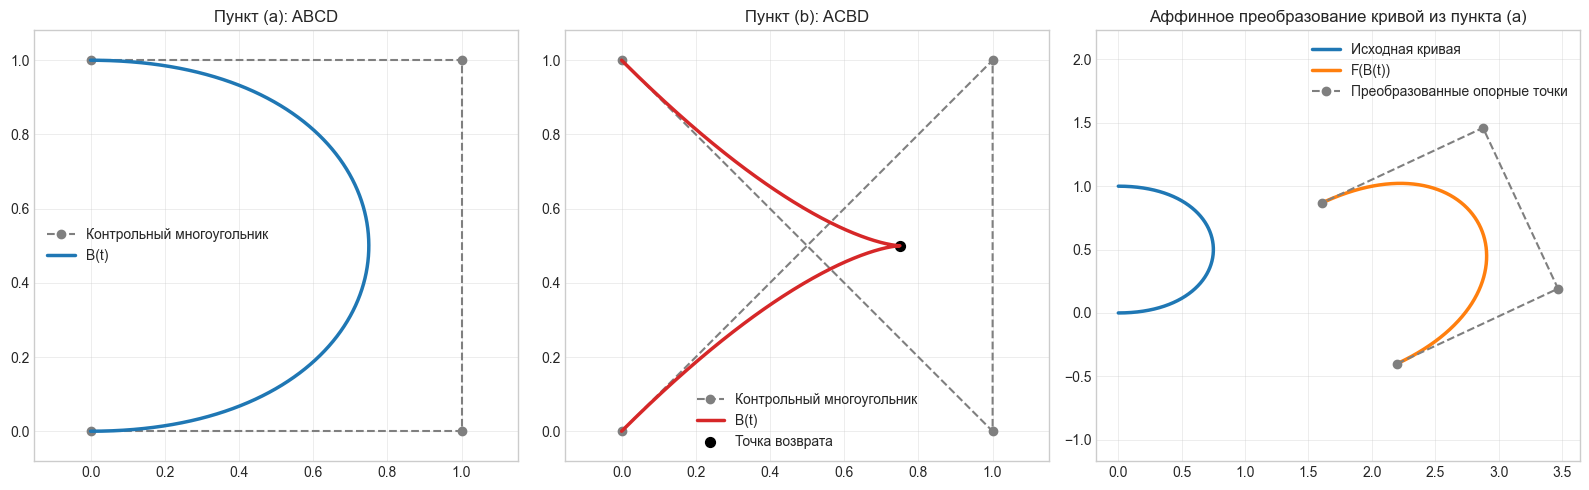

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(simple_control[:, 0], simple_control[:, 1], "o--", color="tab:gray", label="Контрольный многоугольник")
axes[0].plot(simple_curve[:, 0], simple_curve[:, 1], color="tab:blue", linewidth=2.5, label="B(t)")
axes[0].set_title("Пункт (a): ABCD")
axes[0].axis("equal")
axes[0].legend()

axes[1].plot(cusp_control[:, 0], cusp_control[:, 1], "o--", color="tab:gray", label="Контрольный многоугольник")
axes[1].plot(cusp_curve[:, 0], cusp_curve[:, 1], color="tab:red", linewidth=2.5, label="B(t)")
axes[1].scatter(*cusp_point, color="black", s=50, label="Точка возврата")
axes[1].set_title("Пункт (b): ACBD")
axes[1].axis("equal")
axes[1].legend()

axes[2].plot(simple_curve[:, 0], simple_curve[:, 1], color="tab:blue", linewidth=2.5, label="Исходная кривая")
axes[2].plot(transformed_simple_curve[:, 0], transformed_simple_curve[:, 1], color="tab:orange", linewidth=2.5, label="F(B(t))")
axes[2].plot(transformed_simple_control[:, 0], transformed_simple_control[:, 1], "o--", color="tab:gray", label="Преобразованные опорные точки")
axes[2].set_title("Аффинное преобразование кривой из пункта (a)")
axes[2].axis("equal")
axes[2].legend()

plt.tight_layout()
plt.show()


### Часть II. Контур объекта сложной формы

В качестве объекта выбрана **рыба**.

Используются разные типы кривых:
- сплайн Катмулла-Рома задает спину и брюхо;
- квадратичные кривые Безье задают хвост;
- кубические кривые Безье задают плавники.


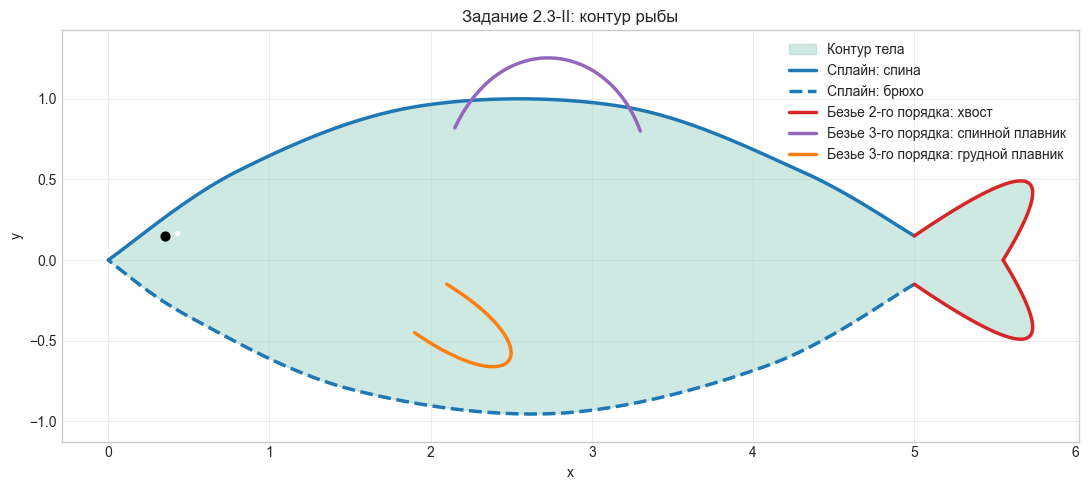

In [9]:
back_spline_points = np.array([
    [0.0, 0.0],
    [0.8, 0.55],
    [1.9, 0.95],
    [3.2, 0.95],
    [4.3, 0.55],
    [5.0, 0.15],
])

belly_spline_points = np.array([
    [5.0, -0.15],
    [4.1, -0.65],
    [2.8, -0.95],
    [1.5, -0.8],
    [0.5, -0.35],
    [0.0, 0.0],
])

back_curve = catmull_rom_open(back_spline_points, samples_per_segment=50)
belly_curve = catmull_rom_open(belly_spline_points, samples_per_segment=50)

upper_tail_control = np.array([[5.0, 0.15], [6.1, 0.9], [5.55, 0.0]])
lower_tail_control = np.array([[5.55, 0.0], [6.1, -0.9], [5.0, -0.15]])
dorsal_fin_control = np.array([[2.15, 0.82], [2.45, 1.45], [3.1, 1.35], [3.3, 0.8]])
pectoral_fin_control = np.array([[2.1, -0.15], [2.75, -0.55], [2.55, -0.9], [1.9, -0.45]])

upper_tail = bezier_quadratic(upper_tail_control, np.linspace(0.0, 1.0, 120))
lower_tail = bezier_quadratic(lower_tail_control, np.linspace(0.0, 1.0, 120))
dorsal_fin = bezier_cubic(dorsal_fin_control, np.linspace(0.0, 1.0, 120))
pectoral_fin = bezier_cubic(pectoral_fin_control, np.linspace(0.0, 1.0, 120))

fish_outline = np.vstack([back_curve, upper_tail[1:], lower_tail[1:], belly_curve[1:]])

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill(fish_outline[:, 0], fish_outline[:, 1], color="#9fd3c7", alpha=0.5, label="Контур тела")
ax.plot(back_curve[:, 0], back_curve[:, 1], color="tab:blue", linewidth=2.5, label="Сплайн: спина")
ax.plot(belly_curve[:, 0], belly_curve[:, 1], color="tab:blue", linewidth=2.5, linestyle="--", label="Сплайн: брюхо")
ax.plot(upper_tail[:, 0], upper_tail[:, 1], color="tab:red", linewidth=2.5, label="Безье 2-го порядка: хвост")
ax.plot(lower_tail[:, 0], lower_tail[:, 1], color="tab:red", linewidth=2.5)
ax.plot(dorsal_fin[:, 0], dorsal_fin[:, 1], color="tab:purple", linewidth=2.5, label="Безье 3-го порядка: спинной плавник")
ax.plot(pectoral_fin[:, 0], pectoral_fin[:, 1], color="tab:orange", linewidth=2.5, label="Безье 3-го порядка: грудной плавник")
ax.scatter([0.35], [0.15], s=40, color="black")
ax.scatter([0.43], [0.17], s=10, color="white", zorder=3)

ax.set_title("Задание 2.3-II: контур рыбы")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis("equal")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


## Задание 2.4. Растровое изображение линий

Возьмем отрезок с концами:
- `P = (2, 3)`
- `Q = (18, 10)`

Построим его растровое изображение:
- алгоритмом Брезенхейма;
- естественным алгоритмом по уравнению прямой.

Затем применим к отрезку:
- перенос на вектор `(4, 2)`;
- поворот на `28°` вокруг уже перенесенной точки `P'`.

После преобразования точные концы отрезка становятся нецелыми, поэтому для растрового изображения используются ближайшие узлы решетки.


In [10]:
segment_start = np.array([2.0, 3.0])
segment_end = np.array([18.0, 10.0])

segment_shift = np.array([4.0, 2.0])
translated_start = segment_start + segment_shift

segment_transform = rotation_about(28.0, tuple(translated_start)) @ translation(*segment_shift)
transformed_segment = apply_transform(segment_transform, np.vstack([segment_start, segment_end]))
transformed_segment_int = np.round(transformed_segment).astype(int)

original_natural = natural_line_pixels(segment_start, segment_end)
original_bresenham = bresenham_line(segment_start, segment_end)
transformed_natural = natural_line_pixels(transformed_segment_int[0], transformed_segment_int[1])
transformed_bresenham = bresenham_line(transformed_segment_int[0], transformed_segment_int[1])

print("Исходный отрезок:", segment_start, segment_end)
print("Точный образ после переноса и поворота:")
print(transformed_segment)
print()
print("Узлы решетки для растеризации преобразованного отрезка:")
print(transformed_segment_int)
print()
print("Совпадение множеств пикселей для исходного отрезка:",
      set(original_natural) == set(original_bresenham))
print("Совпадение множеств пикселей для преобразованного отрезка:",
      set(transformed_natural) == set(transformed_bresenham))


Исходный отрезок: [2. 3.] [18. 10.]
Точный образ после переноса и поворота:
[[ 6.      5.    ]
 [16.8409 18.6922]]

Узлы решетки для растеризации преобразованного отрезка:
[[ 6  5]
 [17 19]]

Совпадение множеств пикселей для исходного отрезка: True
Совпадение множеств пикселей для преобразованного отрезка: False


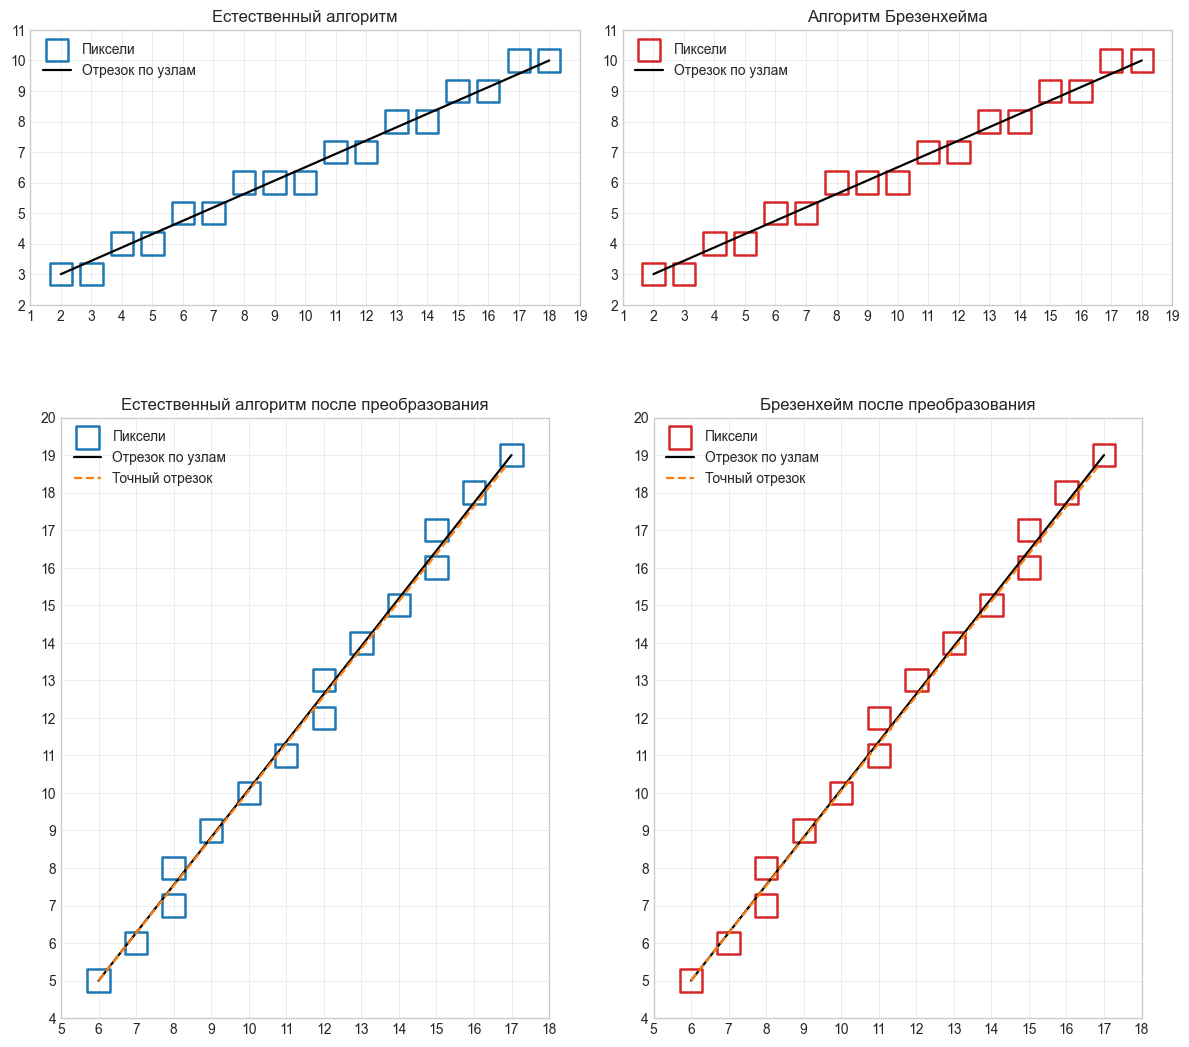

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

draw_raster(
    axes[0, 0],
    original_natural,
    segment_start,
    segment_end,
    "Естественный алгоритм",
    "tab:blue",
)

draw_raster(
    axes[0, 1],
    original_bresenham,
    segment_start,
    segment_end,
    "Алгоритм Брезенхейма",
    "tab:red",
)

draw_raster(
    axes[1, 0],
    transformed_natural,
    transformed_segment_int[0],
    transformed_segment_int[1],
    "Естественный алгоритм после преобразования",
    "tab:blue",
    exact_start=transformed_segment[0],
    exact_end=transformed_segment[1],
)

draw_raster(
    axes[1, 1],
    transformed_bresenham,
    transformed_segment_int[0],
    transformed_segment_int[1],
    "Брезенхейм после преобразования",
    "tab:red",
    exact_start=transformed_segment[0],
    exact_end=transformed_segment[1],
)

plt.tight_layout()
plt.show()


## Вывод

В ноутбуке выполнены все задания лабораторной №2:
- квадрика переведена из окружности в эллипс аффинным преобразованием и проверена аналитически;
- для эллипса и архимедовой спирали найдены касательные, нормали, кривизны, радиусы кривизны и эволюты;
- для кубических кривых Безье перебраны все перестановки вершин квадрата, найдены варианты с выпуклой кривой и с точкой возврата, а также показано отсутствие самопересечений;
- смоделирован контур сложного объекта комбинацией сплайнов и кривых Безье 2-го и 3-го порядка;
- построены растровые изображения исходного и преобразованного отрезков двумя алгоритмами.
